# **Coffee Shop Sales Analysis**



# **Libraries Importing**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

# **Data Exploration**

In [ ]:
# Load the dataset
df = pd.read_csv('coffeeshopsales.csv')

In [ ]:
# Show the first few rows of the dataset
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,1/1/2023,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,1/1/2023,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,1/1/2023,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,1/1/2023,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,1/1/2023,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [ ]:
# Show the last few rows of the dataset
df.tail()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
149111,149452,6/30/2023,20:18:41,2,8,Hell's Kitchen,44,2.50,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,6/30/2023,20:25:10,2,8,Hell's Kitchen,49,3.00,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,6/30/2023,20:31:34,1,8,Hell's Kitchen,45,3.00,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,6/30/2023,20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino
149115,149456,6/30/2023,20:57:19,2,8,Hell's Kitchen,64,0.80,Flavours,Regular syrup,Hazelnut syrup


In [ ]:
# Brief info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   transaction_date  149116 non-null  object 
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  object 
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  object 
 9   product_type      149116 non-null  object 
 10  product_detail    149116 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 12.5+ MB


In [ ]:
# Descriptive statistics of the dataset
df.describe()

,transaction_id,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,1.438276,5.342063,47.918607,3.382219
std,43153.600016,0.542509,2.074241,17.930020,2.658723
min,1.000000,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2.000000,8.000000,60.000000,3.750000
max,149456.000000,8.000000,8.000000,87.000000,45.000000


In [ ]:
# Rows of the dataset
df.index

RangeIndex(start=0, stop=149116, step=1)

In [ ]:
# Columns of the dataset
df.columns

Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='object')

In [ ]:
# Unique attributes of the dataset
df.nunique()

,0
transaction_id,149116
transaction_date,181
transaction_time,25762
transaction_qty,6
store_id,3
store_location,3
product_id,80
unit_price,41
product_category,9
product_type,29


In [ ]:
# Data types in the dataset
df.dtypes

,0
transaction_id,int64
transaction_date,object
transaction_time,object
transaction_qty,int64
store_id,int64
store_location,object
product_id,int64
unit_price,float64
product_category,object
product_type,object


# **Data Cleaning**

In [ ]:
# Identify missing values
df.isnull().sum()

,0
transaction_id,0
transaction_date,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


In [ ]:
# Identify duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
# Convert 'transaction_date' and 'transaction_time' to datetime objects
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['transaction_time'] = pd.to_datetime(df['transaction_time']).dt.time

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Handle duplicate rows if any (dropping them in this case)
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Number of rows after dropping duplicates: {len(df)}")

# Verify data types
print(df.info())

/tmp/ipython-input-521851201.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['transaction_time'] = pd.to_datetime(df['transaction_time']).dt.time


Number of duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB
None


**Reasoning**:
Check for inconsistencies in categorical columns.



In [ ]:
# Check unique values in categorical columns
categorical_cols = ['store_location', 'product_category', 'product_type', 'product_detail']
for col in categorical_cols:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print("-" * 30)

Unique values in 'store_location':
['Lower Manhattan' "Hell's Kitchen" 'Astoria']
------------------------------
Unique values in 'product_category':
['Coffee' 'Tea' 'Drinking Chocolate' 'Bakery' 'Flavours' 'Loose Tea'
 'Coffee beans' 'Packaged Chocolate' 'Branded']
------------------------------
Unique values in 'product_type':
['Gourmet brewed coffee' 'Brewed Chai tea' 'Hot chocolate' 'Drip coffee'
 'Scone' 'Barista Espresso' 'Brewed Black tea' 'Brewed Green tea'
 'Brewed herbal tea' 'Biscotti' 'Pastry' 'Organic brewed coffee'
 'Premium brewed coffee' 'Regular syrup' 'Herbal tea' 'Gourmet Beans'
 'Organic Beans' 'Sugar free syrup' 'Drinking Chocolate' 'Premium Beans'
 'Chai tea' 'Green beans' 'Espresso Beans' 'Green tea' 'Organic Chocolate'
 'Housewares' 'Black tea' 'House blend Beans' 'Clothing']
------------------------------
Unique values in 'product_detail':
['Ethiopia Rg' 'Spicy Eye Opener Chai Lg' 'Dark chocolate Lg'
 'Our Old Time Diner Blend Sm' 'Oatmeal Scone' 'Columbian Med

# **Analysis Preparation**


In [ ]:
# Create sale_price column
df['sale_price'] = df['transaction_qty'] * df['unit_price']

# Convert transaction_date to datetime objects if not already
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract day of the week and month
df['day_of_week'] = df['transaction_date'].dt.day_name()
df['month'] = df['transaction_date'].dt.month_name()

# Calculate total sales for each product_detail
total_sales_per_product = df.groupby('product_detail')['sale_price'].sum()

# Calculate total quantity sold for each product_detail
total_quantity_sold_per_product = df.groupby('product_detail')['transaction_qty'].sum()

display(df.head())
display(total_sales_per_product.head())
display(total_quantity_sold_per_product.head())

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,cost,sale_price,day_of_week,month
0,1,2023-01-01,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2.40,6.0,Sunday,January
1,2,2023-01-01,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2.48,6.2,Sunday,January
2,3,2023-01-01,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,3.60,9.0,Sunday,January
3,4,2023-01-01,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,0.80,2.0,Sunday,January
4,5,2023-01-01,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2.48,6.2,Sunday,January


,sale_price
product_detail,
Almond Croissant,7168.13
Brazilian - Organic,3852.00
Brazilian Lg,15109.50
Brazilian Rg,13155.00
Brazilian Sm,9482.00


,transaction_qty
product_detail,
Almond Croissant,1911
Brazilian - Organic,214
Brazilian Lg,4317
Brazilian Rg,4385
Brazilian Sm,4310


# **Profit / Loss Analysis**


In [ ]:
# Assume a cost percentage (e.g., 40%)
cost_percentage = 0.40

# Calculate the cost of each transaction
df['cost'] = df['unit_price'] * cost_percentage * df['transaction_qty']

# Calculate the profit for each transaction
df['profit'] = df['sale_price'] - df['cost']

# Calculate the total profit for each product detail
total_profit_per_product = df.groupby('product_detail')['profit'].sum()

# Sort products by total profit in descending order
top_10_profitable_products = total_profit_per_product.sort_values(ascending=False).head(10)

# Sort products by total profit in ascending order
least_profitable_products = total_profit_per_product.sort_values(ascending=True).head(10)

# Display the top 10 most profitable products
print("Top 10 Most Profitable Products:")
display(top_10_profitable_products)

# Display the 10 least profitable products
print("\n10 Least Profitable Products:")
display(least_profitable_products)

Top 10 Most Profitable Products:


,profit
product_detail,
Sustainably Grown Organic Lg,12691.05
Dark chocolate Lg,12603.60
Latte Rg,11467.35
Cappuccino Lg,10585.05
Morning Sunrise Chai Lg,10430.40
Latte,10354.50
Jamaican Coffee River Lg,9888.75
Sustainably Grown Organic Rg,9740.25
Cappuccino,9598.50



10 Least Profitable Products:


,profit
product_detail,
Dark chocolate,453.12
Earl Grey,762.54
Spicy Eye Opener Chai,801.54
Guatemalan Sustainably Grown,804.00
Lemon Grass,816.24
Peppermint,821.61
Traditional Blend Chai,821.61
English Breakfast,864.57
Serenity Green Tea,882.45


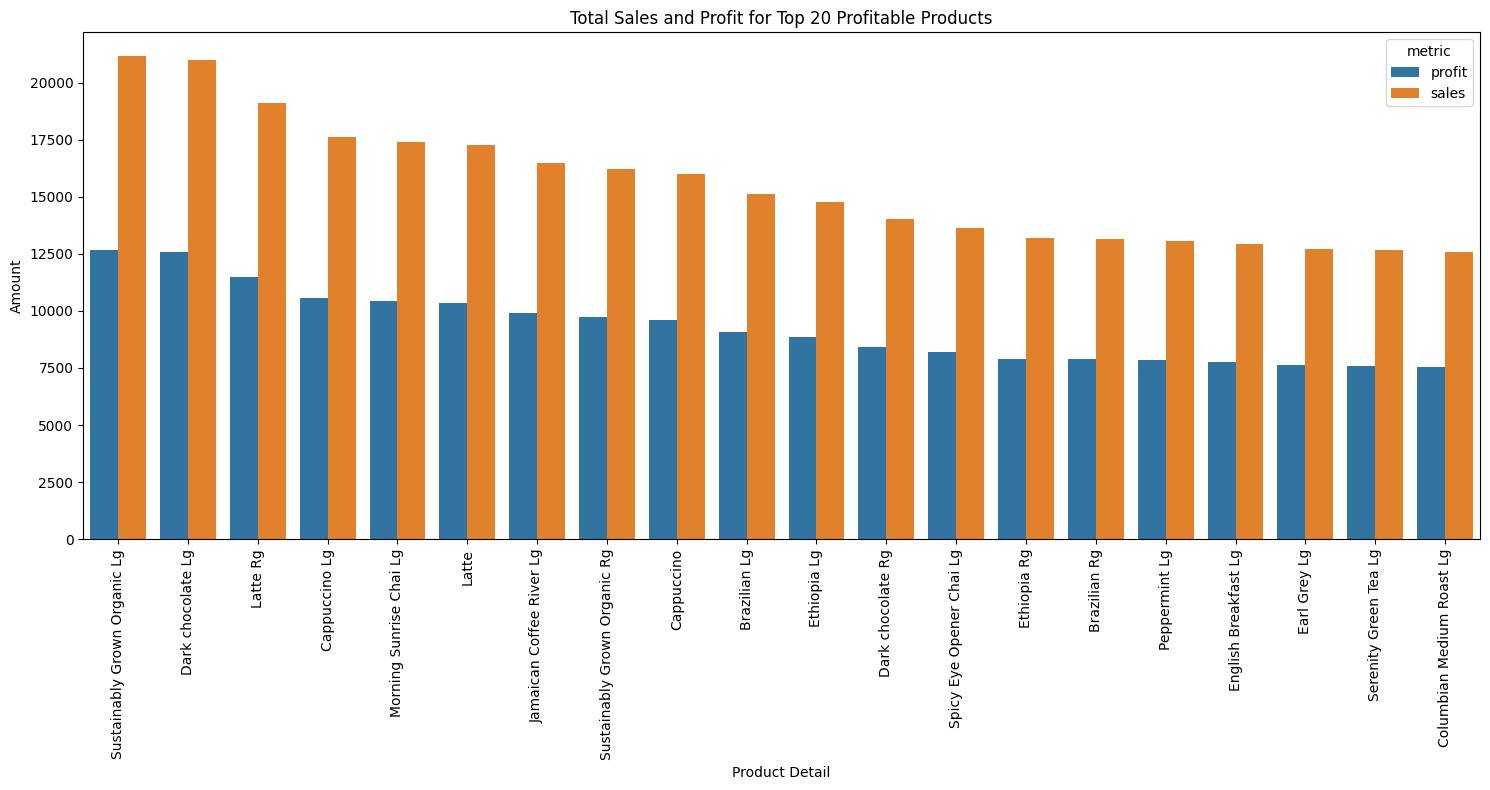

In [ ]:
# Select top 20 products by profit for visualization
top_20_profitable_products = total_profit_per_product.sort_values(ascending=False).head(20)

# Get the corresponding sales for the top 20 profitable products
top_20_sales = total_sales_per_product.loc[top_20_profitable_products.index]

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'product_detail': top_20_profitable_products.index,
    'profit': top_20_profitable_products.values,
    'sales': top_20_sales.values
})

# Melt the DataFrame for easier plotting with seaborn
melted_plot_df = plot_df.melt(id_vars='product_detail', var_name='metric', value_name='amount')

# Plotting total sales and profit for the top 20 products
plt.figure(figsize=(15, 8))
sns.barplot(x='product_detail', y='amount', hue='metric', data=melted_plot_df)
plt.xticks(rotation=90)
plt.title('Total Sales and Profit for Top 20 Profitable Products')
plt.xlabel('Product Detail')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

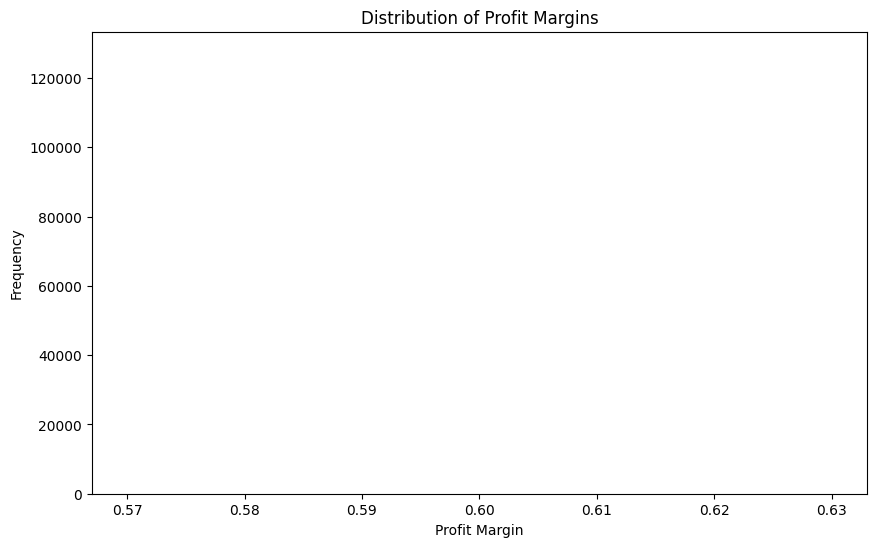

In [ ]:
# Calculate profit margin for each transaction
df['profit_margin'] = df['profit'] / df['sale_price']

# Visualize the distribution of profit margins
plt.figure(figsize=(10, 6))
sns.histplot(df['profit_margin'], bins=20, kde=True)
plt.title('Distribution of Profit Margins')
plt.xlabel('Profit Margin')
plt.ylabel('Frequency')
plt.show()

# **Profit Increase Prediction (If Applicable)**

In [ ]:
# Group by transaction_date and product_detail and sum the profit
daily_profit_per_product = df.groupby(['transaction_date', 'product_detail'])['profit'].sum()

# Unstack the resulting dataframe
daily_profit_per_product_unstacked = daily_profit_per_product.unstack()

# Fill any missing values with 0
daily_profit_per_product_unstacked = daily_profit_per_product_unstacked.fillna(0)

display(daily_profit_per_product_unstacked.head())

product_detail,Almond Croissant,Brazilian - Organic,Brazilian Lg,Brazilian Rg,Brazilian Sm,Cappuccino,Cappuccino Lg,Carmel syrup,Chili Mayan,Chocolate Chip Biscotti,...,Spicy Eye Opener Chai,Spicy Eye Opener Chai Lg,Spicy Eye Opener Chai Rg,Sugar Free Vanilla syrup,Sustainably Grown Organic,Sustainably Grown Organic Lg,Sustainably Grown Organic Rg,Traditional Blend Chai,Traditional Blend Chai Lg,Traditional Blend Chai Rg
transaction_date,,,,,,,,,,,,,,,,,,,,,
2023-01-01,4.50,0.0,42.0,25.2,30.36,54.00,45.90,0.0,0.0,14.7,...,0.0,29.76,30.60,0.0,0.0,45.60,63.00,0.0,30.6,19.5
2023-01-02,15.75,0.0,46.2,48.6,29.04,29.25,28.05,0.0,0.0,12.6,...,0.0,22.32,19.89,0.0,0.0,45.60,36.00,0.0,32.4,43.5
2023-01-03,15.75,0.0,52.5,41.4,33.00,24.75,30.60,0.0,0.0,16.8,...,0.0,31.62,26.01,0.0,0.0,62.70,33.75,0.0,23.4,24.0
2023-01-04,15.75,0.0,50.4,25.2,21.12,38.25,17.85,0.0,0.0,14.7,...,0.0,33.48,30.60,0.0,0.0,34.20,31.50,0.0,18.0,19.5
2023-01-05,6.75,0.0,33.6,21.6,22.44,42.75,51.00,0.0,0.0,4.2,...,0.0,26.04,32.13,0.0,0.0,48.45,56.25,0.0,10.8,25.5


In [ ]:
# Select top 5 most profitable products
top_5_products = top_10_profitable_products.head(5).index.tolist()

# Select top 5 least profitable products
least_5_products = least_profitable_products.head(5).index.tolist()

# Combine the lists of products
selected_products = top_5_products + least_5_products

# Create a dictionary to store time series data for each selected product
time_series_data = {}

# For each selected product, prepare the time series data
for product in selected_products:
    if product in daily_profit_per_product_unstacked.columns:
        time_series_data[product] = daily_profit_per_product_unstacked[product]

# Display the first few rows of the time series data for the first selected product as an example
if time_series_data:
    first_product = list(time_series_data.keys())[0]
    print(f"Time series data for {first_product}:")
    display(time_series_data[first_product].head())
else:
    print("No selected products found in the daily profit data.")

Time series data for Sustainably Grown Organic Lg:


,Sustainably Grown Organic Lg
transaction_date,
2023-01-01,45.60
2023-01-02,45.60
2023-01-03,62.70
2023-01-04,34.20
2023-01-05,48.45


In [ ]:
# Create a dictionary to store fitted models
fitted_models = {}

# Fit an ARIMA model for each selected product
for product, data in time_series_data.items():
    try:
        # Use a simple ARIMA(5,1,0) model as a starting point
        model = ARIMA(data, order=(5, 1, 0))
        model_fit = model.fit()
        fitted_models[product] = model_fit
        print(f"ARIMA model fitted successfully for {product}")
        # Display model summary for the first fitted model as an example
        if len(fitted_models) == 1:
            print(model_fit.summary())
    except Exception as e:
        print(f"Could not fit ARIMA model for {product}: {e}")


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA model fitted successfully for Sustainably Grown Organic Lg
                                    SARIMAX Results                                     
Dep. Variable:     Sustainably Grown Organic Lg   No. Observations:                  181
Model:                           ARIMA(5, 1, 0)   Log Likelihood                -796.116
Date:                          Tue, 12 Aug 2025   AIC                           1604.232
Time:                                  15:40:18   BIC                           1623.390
Sample:                              01-01-2023   HQIC                          1612.000
                                   - 06-30-2023                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9337      0.073    -12.843      0.000      -1.07

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA model fitted successfully for Dark chocolate Lg


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


...

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

ARIMA model fitted successfully for Dark chocolate
ARIMA model fitted successfully for Earl Grey
ARIMA model fitted successfully for Spicy Eye Opener Chai


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

ARIMA model fitted successfully for Guatemalan Sustainably Grown
ARIMA model fitted successfully for Lemon Grass


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [ ]:
# Provide recommendations based on profitability analysis and model insights

print("Recommendations for Increasing Profit Margins:")

# Recommendations based on profitability analysis
print("\nBased on the profitability analysis:")
print("- Focus marketing and sales efforts on the top 5 most profitable products:")
for product in top_5_products:
    print(f"  - {product}")
print("- Analyze the reasons for low profitability in the least profitable products and consider strategies such as:")
for product in least_5_products:
    print(f"  - {product}")
print("    - Optimizing pricing.")
print("    - Reducing production/sourcing costs.")
print("    - Improving marketing or placement.")
print("    - Considering discontinuation if efforts to improve profitability are unsuccessful.")

# Recommendations based on model insights (example based on ARIMA parameters)
print("\nBased on the ARIMA model insights (trends, seasonality):")
print("- For products with positive trend components, consider scaling up production or stocking levels to meet growing demand.")
print("- For products with significant seasonality, align inventory and marketing campaigns with peak seasons.")
print("- Investigate the factors driving any observed trends or seasonal patterns to capitalize on opportunities or mitigate risks.")
print("- Continuously monitor model performance and retrain models as new data becomes available.")

print("\nOverall Recommendations:")
print("- Conduct a detailed cost analysis for each product to identify areas for cost reduction.")
print("- Explore opportunities for price optimization based on market demand and competitor pricing.")
print("- Implement targeted marketing strategies to promote high-margin products.")
print("- Enhance operational efficiency to reduce overhead costs.")

Recommendations for Increasing Profit Margins:

Based on the profitability analysis:
- Focus marketing and sales efforts on the top 5 most profitable products:
  - Sustainably Grown Organic Lg
  - Dark chocolate Lg
  - Latte Rg
  - Cappuccino Lg
  - Morning Sunrise Chai Lg
- Analyze the reasons for low profitability in the least profitable products and consider strategies such as:
  - Dark chocolate
  - Earl Grey
  - Spicy Eye Opener Chai
  - Guatemalan Sustainably Grown
  - Lemon Grass
    - Optimizing pricing.
    - Reducing production/sourcing costs.
    - Improving marketing or placement.
    - Considering discontinuation if efforts to improve profitability are unsuccessful.

Based on the ARIMA model insights (trends, seasonality):
- For products with positive trend components, consider scaling up production or stocking levels to meet growing demand.
- For products with significant seasonality, align inventory and marketing campaigns with peak seasons.
- Investigate the factors dri

# **Loss Mitigation (If Applicable)**

In [ ]:
# Identify the least profitable products (already available in least_profitable_products)
print("Least Profitable Products:")
display(least_profitable_products)

# Analyze potential contributing factors for each least profitable product
print("\nAnalysis of Factors Contributing to Low Profitability for Least Profitable Products:")

for product in least_profitable_products.index:
    print(f"\nProduct: {product}")

    # Check total profit
    profit = total_profit_per_product.get(product, 0)
    print(f"- Total Profit: {profit:.2f}")

    # Check total sales volume
    sales_volume = total_quantity_sold_per_product.get(product, 0)
    print(f"- Total Quantity Sold: {sales_volume}")

    # Check total sales revenue
    sales_revenue = total_sales_per_product.get(product, 0)
    print(f"- Total Sales Revenue: {sales_revenue:.2f}")

    # Discuss potential factors based on the values
    if sales_volume < total_quantity_sold_per_product.mean():
        print("- Potential Factor: Low sales volume compared to the average product.")
    if profit < 1000: # Example threshold for low profit
         print("- Potential Factor: Relatively low total profit.")

    # Discuss unit price relative to cost (conceptual, as cost_percentage is fixed)
    print("- Note: With a fixed cost percentage, low profit per unit is directly tied to low unit price.")
    print("  A detailed cost analysis would be crucial to understand true cost per unit and profit margin.")


# Propose mitigation strategies for the least profitable products
print("\nProposed Strategies to Mitigate Low Profitability:")
for product in least_profitable_products.index:
    print(f"\nProduct: {product}")
    print("- Price adjustments: Consider slightly increasing the unit price if market conditions allow.")
    print("- Cost reduction: Explore opportunities for reducing sourcing or production costs (requires detailed cost analysis).")
    print("- Marketing and promotion: Implement targeted campaigns to increase awareness and sales volume.")
    print("- Product bundling: Offer bundles with more popular or higher-margin products.")
    print("- Placement: Optimize product placement in stores or on the menu to increase visibility.")
    print("- Discontinuation: If efforts to improve profitability are unsuccessful after a defined period, consider discontinuing the product.")

# Summarize the analysis and proposed mitigation strategies
print("\nSummary:")
print("The analysis identified several products with the lowest total profit. For these products, potential contributing factors include relatively low sales volume and the impact of a fixed cost percentage on products with lower unit prices. Proposed mitigation strategies involve price adjustments, cost reduction exploration, marketing efforts, product bundling or placement, and potential discontinuation if other strategies are ineffective.")

Least Profitable Products:


,profit
product_detail,
Dark chocolate,453.12
Earl Grey,762.54
Spicy Eye Opener Chai,801.54
Guatemalan Sustainably Grown,804.00
Lemon Grass,816.24
Peppermint,821.61
Traditional Blend Chai,821.61
English Breakfast,864.57
Serenity Green Tea,882.45



Analysis of Factors Contributing to Low Profitability for Least Profitable Products:

Product: Dark chocolate
- Total Profit: 453.12
- Total Quantity Sold: 118
- Total Sales Revenue: 755.20
- Potential Factor: Low sales volume compared to the average product.
- Potential Factor: Relatively low total profit.
- Note: With a fixed cost percentage, low profit per unit is directly tied to low unit price.
  A detailed cost analysis would be crucial to understand true cost per unit and profit margin.

Product: Earl Grey
- Total Profit: 762.54
- Total Quantity Sold: 142
- Total Sales Revenue: 1270.90
- Potential Factor: Low sales volume compared to the average product.
- Potential Factor: Relatively low total profit.
- Note: With a fixed cost percentage, low profit per unit is directly tied to low unit price.
  A detailed cost analysis would be crucial to understand true cost per unit and profit margin.

Product: Spicy Eye Opener Chai
- Total Profit: 801.54
- Total Quantity Sold: 122
- Total 